### Campaign Finance and Congressional Election Outcomes — Part 1: Exploratory Data Analysis

**Research Question:** Can the amount and source of campaign finance contributions predict whether a U.S. congressional candidate wins or loses their election?

**Goal:** This notebook loads, cleans, and merges data from the Federal Election Commission (FEC) and the MIT Election Data and Science Lab (MEDSL). We explore fundraising distributions, compare winners vs. losers, and identify features for classification modeling in Part 2.

**Data Problem:** The data task is to merge candidate-level financial data (contributions, disbursements, PAC money, individual donations) with historical win/loss outcomes, and produce a clean, analysis-ready dataset.

#### Business Understanding

**Why does this problem matter?**

Campaign finance is one of the most contested issues in American democracy. Every election cycle, billions of dollars flow through congressional campaigns — yet we lack rigorous, data-driven answers to a basic question: does money actually determine who wins?

**Who are the stakeholders?**

- **Voters and journalists** who want to understand whether financial advantages translate to electoral power
- **Reform advocates and policy organizations** (e.g., Common Cause, Issue One) who argue for stricter contribution limits or public financing programs
- **Legislators and regulators** at the FEC who set the rules governing political money
- **Campaigns and candidates** who make strategic fundraising decisions

**What decision will this analysis inform?**

This project produces a predictive model that quantifies how much fundraising, PAC money, and party affiliation drive congressional election outcomes. Results can inform whether campaign finance reform efforts are likely to meaningfully change electoral outcomes, and which financial factors matter most.

#### Import and Setup

In [26]:
# standard library and data science imports
import re
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import plotly.express as px
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy import stats

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 40)
pd.set_option('display.float_format', '{:,.2f}'.format)

%matplotlib inline

#### Standard Helper Functions

The following reusable functions are defined once here and called throughout the notebook to keep the analysis clean and consistent.

In [27]:
# ── Helper functions used throughout this notebook ────────────────────────────
def check_null(df, label="DataFrame"):
    """Returns count and percentage of nulls per column."""
    null_counts = df.isna().sum()
    null_pct = (null_counts / len(df) * 100).round(2)
    result = pd.DataFrame({'null_count': null_counts, 'null_pct (%)': null_pct})
    result = result[result['null_count'] > 0]
    if result.empty:
        print(f"{label}: no null values found ✓")
    else:
        print(f"{label}: null values found:")
        print(result)
    return result

def check_duplicate(df, subset, label="DataFrame"):
    """Checks for duplicate rows on a given subset of columns."""
    n_dupes = df.duplicated(subset=subset).sum()
    if n_dupes == 0:
        print(f"{label}: no duplicates on {subset} ✓")
    else:
        print(f"{label}: {n_dupes:,} duplicates on {subset} ⚠")
    return n_dupes

#### Data Sources

This project draws on two publicly available datasets:

1. **FEC Candidate Summary File** — candidate-level fundraising and spending totals for the 2022 election cycle. Downloaded from https://www.fec.gov/data/browse-data/?tab=bulk-data under "Candidate summary files."
2. **MIT Election Data and Science Lab (MEDSL)** — U.S. House election results 1976–2022. Available at https://dataverse.harvard.edu/dataset.xhtml?persistentId=doi:10.7910/DVN/IG0UN2

**Merge strategy:** Because candidate name formats differ substantially between datasets (FEC uses "LAST, FIRST" while MIT uses "FIRST LAST"), we merge on **state + congressional district + party abbreviation** rather than by name. This produces one financial record per party per district, matched to the corresponding candidate's vote totals.

#### Load FEC Data

In [28]:
# ── Load FEC Candidate Summary File ─────────────────────────────────────────
# Comma-delimited CSV with header row. Place in data/ folder as fec_candidates.csv.

fec_raw = pd.read_csv('data/fec_candidates.csv', low_memory=False)

print(f"FEC raw shape: {fec_raw.shape[0]:,} rows x {fec_raw.shape[1]} columns")
check_null(fec_raw, "FEC")
check_duplicate(fec_raw, subset=['Cand_Id'], label="FEC")
fec_raw.head()

FEC raw shape: 4,529 rows x 50 columns
FEC: null values found:
                                     null_count  null_pct (%)
Cand_Office_Dist                            105          2.32
Cand_Party_Affiliation                        2          0.04
Cand_Incumbent_Challenger_Open_Seat           1          0.02
Cash_On_Hand_COP                             11          0.24
Debt_Owed_By_Committee                       22          0.49
Coverage_End_Date                          1873         41.36
Cand_Street_1                                 9          0.20
Cand_Street_2                              3889         85.87
Cand_State                                    1          0.02
Cand_Zip                                      6          0.13
Cash_On_Hand_BOP                             10          0.22
Debt_Owe_To_Committee                        29          0.64
Coverage_Start_Date                        1873         41.36
FEC: no duplicates on ['Cand_Id'] ✓


,Link_Image,Cand_Name,Cand_Id,Cand_Office,Cand_Office_St,Cand_Office_Dist,Cand_Party_Affiliation,Cand_Incumbent_Challenger_Open_Seat,Total_Receipt,Total_Disbursement,Cash_On_Hand_COP,Debt_Owed_By_Committee,Coverage_End_Date,Cand_Street_1,Cand_Street_2,Cand_City,Cand_State,Cand_Zip,Individual_Itemized_Contribution,Individual_Unitemized_Contribution,...,Offsets_To_Fundraising,Offsets_To_Leagal_Accounting,Other_Receipts,Operating_Expenditure,Exempt_Legal_Accounting_Disbursement,Fundraising_Disbursement,Transfer_To_Other_Auth_Committee,Cand_Loan_Repayment,Other_Loan_Repayment,Total_Loan_Repayment,Individual_Refund,Party_Committee_Refund,Other_Committee_Refund,Total_Contribution_Refund,Other_Disbursements,Net_Contribution,Net_Operating_Expenditure,Cash_On_Hand_BOP,Debt_Owe_To_Committee,Coverage_Start_Date
0,https://www.fec.gov/data/candidate/H2CA01185/?...,"GODFREY, MARCUS SCOTT",H2CA01185,H,CA,1.00,LIB,CHALLENGER,0.00,0.00,0.00,0.00,NaN,10448 PEKOLEE DR,NaN,GRASS VALLEY,CA,"95,949.00",0.00,0.00,...,0,0,0.00,0.00,0,0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,NaN
1,https://www.fec.gov/data/candidate/S2MO00502/?...,"NICHOLAS CRANE, STRAUSS",S2MO00502,S,MO,0.00,NaN,OPEN,0.00,0.00,0.00,0.00,NaN,1 BITTER FIELD CT,NaN,BALLWIN,MO,"63,011.00",0.00,0.00,...,0,0,0.00,0.00,0,0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,NaN
2,https://www.fec.gov/data/candidate/S2FL00532/?...,"PINNEY, DWAYNE",S2FL00532,S,FL,0.00,REP,CHALLENGER,0.00,0.00,0.00,0.00,NaN,437 W 24TH ST,NaN,JACKSONVILLE,FL,"32,206.00",0.00,0.00,...,0,0,0.00,0.00,0,0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,NaN
3,https://www.fec.gov/data/candidate/H2AZ04200/?...,"DEHART, VAUGHAN BRANDON BRENDAN",H2AZ04200,H,AZ,4.00,REP,CHALLENGER,0.00,0.00,0.00,0.00,NaN,14313 E 9500 NORTH ST,NaN,VALENTINE,AZ,"86,437.00",0.00,0.00,...,0,0,0.00,0.00,0,0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,NaN
4,https://www.fec.gov/data/candidate/S2WI00367/?...,"NEUBERT, KEITH",S2WI00367,S,WI,0.00,REP,CHALLENGER,0.00,0.00,0.00,0.00,NaN,W 7996 NORTH STREET,NaN,PEMBINE,WI,"54,156.00",0.00,0.00,...,0,0,0.00,0.00,0,0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,NaN


#### Load MIT Election Results

In [29]:
# ── Load MIT Election Results ─────────────────────────────────────────────────
# CSV with header row. Place in data/ folder as mit_results.csv.
# Download from: https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/data/2023/2023-11-07/house.csv

mit_raw = pd.read_csv('data/mit_results.csv', low_memory=False)

print(f"MIT raw shape: {mit_raw.shape[0]:,} rows x {mit_raw.shape[1]} columns")
check_null(mit_raw, "MIT")
check_duplicate(mit_raw, subset=['year', 'state_po', 'district', 'candidate', 'party'], label="MIT")
mit_raw.head()

MIT raw shape: 32,452 rows x 20 columns
MIT: null values found:
        null_count  null_pct (%)
runoff        8656         26.67
party         3858         11.89
MIT: 116 duplicates on ['year', 'state_po', 'district', 'candidate', 'party'] ⚠


,year,state,state_po,state_fips,state_cen,state_ic,office,district,stage,runoff,special,candidate,party,writein,mode,candidatevotes,totalvotes,unofficial,version,fusion_ticket
0,1976,ALABAMA,AL,1,63,41,US HOUSE,1,GEN,False,False,BILL DAVENPORT,DEMOCRAT,False,TOTAL,58906,157170,False,20230706,False
1,1976,ALABAMA,AL,1,63,41,US HOUSE,1,GEN,False,False,JACK EDWARDS,REPUBLICAN,False,TOTAL,98257,157170,False,20230706,False
2,1976,ALABAMA,AL,1,63,41,US HOUSE,1,GEN,False,False,WRITEIN,NaN,True,TOTAL,7,157170,False,20230706,False
3,1976,ALABAMA,AL,1,63,41,US HOUSE,2,GEN,False,False,J CAROLE KEAHEY,DEMOCRAT,False,TOTAL,66288,156362,False,20230706,False
4,1976,ALABAMA,AL,1,63,41,US HOUSE,2,GEN,False,False,"WILLIAM L ""BILL"" DICKINSON",REPUBLICAN,False,TOTAL,90069,156362,False,20230706,False


#### Data Cleaning

In [30]:
# ── Clean and filter FEC data ────────────────────────────────────────────────
# Derive election year from Coverage_End_Date or the URL in Link_Image
fec_raw['CAND_ELECTION_YR'] = pd.to_datetime(
    fec_raw['Coverage_End_Date'], errors='coerce').dt.year
fec_raw['CAND_ELECTION_YR'] = fec_raw['CAND_ELECTION_YR'].fillna(
    fec_raw['Link_Image'].str.extract(r'cycle=(\d{4})')[0].astype(float))

# Keep House candidates from the 2022 cycle only
fec = fec_raw[
    (fec_raw['Cand_Office'] == 'H') &
    (fec_raw['CAND_ELECTION_YR'] == 2022)
].copy()

# Standardize state and district
fec['state_po'] = fec['Cand_Office_St'].str.upper().str.strip()
fec['district'] = fec['Cand_Office_Dist'].fillna(0).astype(int).astype(str).str.zfill(3)

print(f"FEC after filter: {fec.shape[0]:,} House candidates, 2022 cycle")
print(f"States covered: {fec['state_po'].nunique()}")

FEC after filter: 3,548 House candidates, 2022 cycle
States covered: 56


In [31]:
# ── Clean and filter MIT data ─────────────────────────────────────────────────
# Keep 2022 general elections only
mit = mit_raw[
    (mit_raw['year'] == 2022) &
    (mit_raw['stage'] == 'GEN') &
    (mit_raw['office'] == 'US HOUSE')
].copy()

# Standardize district format
mit['district'] = mit['district'].astype(str).str.zfill(3)

# Map full party names to abbreviations to match FEC
party_map = {
    'DEMOCRAT': 'DEM', 'REPUBLICAN': 'REP', 'LIBERTARIAN': 'LIB',
    'GREEN': 'GRE', 'INDEPENDENT': 'IND', 'WORKING FAMILIES': 'WFP'
}
mit['party_abbr'] = mit['party'].str.upper().map(party_map).fillna('OTH')

# Aggregate across voting modes (some states report TOTAL + sub-modes)
mit_agg = mit.groupby(
    ['state_po', 'district', 'candidate', 'party_abbr'], as_index=False
).agg(candidatevotes=('candidatevotes', 'sum'),
      totalvotes=('totalvotes', 'max'))

print(f"MIT after filter: {mit_agg.shape[0]:,} candidate-race rows")
print(f"States covered: {mit_agg['state_po'].nunique()}")

MIT after filter: 1,347 candidate-race rows
States covered: 50


#### Determine Winners

In [32]:
# ── Identify the winner of each race ─────────────────────────────────────────
# Winner = candidate with the most votes in each state+district
mit_agg['vote_share'] = mit_agg['candidatevotes'] / mit_agg['totalvotes']
mit_agg['rank'] = mit_agg.groupby(['state_po', 'district'])['candidatevotes'].rank(
    ascending=False, method='first')
mit_agg['won'] = (mit_agg['rank'] == 1).astype(int)

print("Outcome distribution:")
print(mit_agg['won'].value_counts().rename({0: 'Lost', 1: 'Won'}))
print(f"Win rate: {mit_agg['won'].mean():.3f}")

Outcome distribution:
won
Lost    912
Won     435
Name: count, dtype: int64
Win rate: 0.323


#### Merge FEC and MIT Data

In [33]:
# ── Aggregate FEC to state + district + party level ──────────────────────────
# Because name formats differ between datasets, we match on state + district + party.
# This gives us the total financial activity for each party's candidate(s) per district.

fec_agg = fec.groupby(['state_po', 'district', 'Cand_Party_Affiliation'], as_index=False).agg(
    total_raised      = ('Total_Receipt', 'sum'),
    total_spent       = ('Total_Disbursement', 'sum'),
    indiv_contrib     = ('Individual_Contribution', 'sum'),
    pac_contrib       = ('Other_Committee_Contribution', 'sum'),
    party_contrib     = ('Party_Committee_Contribution', 'sum'),
    cand_contrib      = ('Cand_Contribution', 'sum'),
    cand_loan         = ('Cand_Loan', 'sum'),
    n_candidates      = ('Cand_Name', 'count')
).rename(columns={'Cand_Party_Affiliation': 'party_abbr'})

print(f"FEC aggregated: {fec_agg.shape[0]:,} state+district+party rows")

FEC aggregated: 1,367 state+district+party rows


In [34]:
# ── Merge MIT results with FEC financial totals ───────────────────────────────
df = pd.merge(
    mit_agg,
    fec_agg,
    on=['state_po', 'district', 'party_abbr'],
    how='inner'
)

print(f"Merged shape: {df.shape[0]:,} rows x {df.shape[1]} columns")

# preview merged dataset
df[['candidate', 'state_po', 'district', 'party_abbr',
    'total_raised', 'candidatevotes', 'won']].head(8)

Merged shape: 1,048 rows x 17 columns


,candidate,state_po,district,party_abbr,total_raised,candidatevotes,won
0,CHRIS BYE,AK,000,LIB,"8,018.91",4570,0
1,MARY SATTLER PELTOLA,AK,000,DEM,"7,932,148.36",128553,1
2,NICK BEGICH,AK,000,REP,"4,093,230.76",61513,0
3,SARAH PALIN,AK,000,REP,"4,093,230.76",67866,0
4,WRITEIN,AK,000,OTH,0.00,1108,0
5,ALEXANDER M REMREY,AL,001,LIB,0.00,26369,0
6,JERRY L CARL,AL,001,REP,"1,313,718.57",140592,1
7,BARRY MOORE,AL,002,REP,"1,253,849.51",137460,1


#### Feature Engineering

In [35]:
# ── Create analytical features ────────────────────────────────────────────────
# PAC share of total fundraising
df['pac_share'] = np.where(df['total_raised'] > 0,
                            df['pac_contrib'] / df['total_raised'], 0)

# Individual donor share
df['indiv_share'] = np.where(df['total_raised'] > 0,
                              df['indiv_contrib'] / df['total_raised'], 0)

# Fundraising-to-spending ratio
df['raise_spend_ratio'] = np.where(df['total_spent'] > 0,
                                    df['total_raised'] / df['total_spent'], 0)

# Self-funding
df['self_funded'] = df['cand_contrib'] + df['cand_loan']

# Party flags
df['is_democrat']   = (df['party_abbr'] == 'DEM').astype(int)
df['is_republican'] = (df['party_abbr'] == 'REP').astype(int)

# Log-transform of fundraising (handles right skew)
df['log_raised'] = np.log1p(df['total_raised'])
df['log_spent']  = np.log1p(df['total_spent'])

print('Features created. Final dataset shape:', df.shape)

Features created. Final dataset shape: (1048, 25)


#### Data Overview

In [36]:
# dataset structure — column names and dtypes
print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
print()
print(df.dtypes.to_string())

Shape: 1,048 rows x 25 columns

state_po              object
district              object
candidate             object
party_abbr            object
candidatevotes         int64
totalvotes             int64
vote_share           float64
rank                 float64
won                    int64
total_raised         float64
total_spent          float64
indiv_contrib        float64
pac_contrib          float64
party_contrib        float64
cand_contrib         float64
cand_loan            float64
n_candidates           int64
pac_share            float64
indiv_share          float64
raise_spend_ratio    float64
self_funded          float64
is_democrat            int64
is_republican          int64
log_raised           float64
log_spent            float64


In [37]:
# descriptive statistics for key numeric columns
numeric_cols = ['total_raised', 'total_spent', 'indiv_contrib', 'pac_contrib',
                'pac_share', 'indiv_share', 'raise_spend_ratio']
df[numeric_cols].describe()

,total_raised,total_spent,indiv_contrib,pac_contrib,pac_share,indiv_share,raise_spend_ratio
count,"1,048.00","1,048.00","1,048.00","1,048.00","1,048.00","1,048.00","1,048.00"
mean,"1,926,005.54","1,866,869.25","1,272,879.33","357,979.08",0.15,0.53,1.12
std,"3,022,677.30","2,992,340.89","2,357,929.46","499,250.37",0.19,0.32,5.14
min,0.00,"-1,632.00",0.00,0.00,0.00,0.00,0.00
25%,"28,211.85","25,745.56","15,490.38",0.00,0.00,0.30,0.91
50%,"946,957.16","843,114.32","500,849.15","69,650.56",0.06,0.58,1.00
75%,"2,695,537.58","2,483,461.45","1,591,131.01","564,318.75",0.25,0.80,1.07
max,"28,295,639.53","28,863,841.45","24,796,009.32","3,315,554.82",1.00,1.00,117.96


In [38]:
# check for nulls in key columns
key_cols = ['total_raised', 'total_spent', 'pac_share', 'indiv_share', 'won']
check_null(df[key_cols], label="Merged dataset")

Merged dataset: no null values found ✓


,null_count,null_pct (%)


#### Data Cleaning

In [39]:
# Remove candidates with zero fundraising (likely data artifacts or very minor candidates)
before = len(df)
df = df[df['total_raised'] > 0].copy()
print(f"Removed {before - len(df):,} zero-fundraising rows. Remaining: {len(df):,}")
print(f"Win rate after filter: {df['won'].mean():.3f}")

Removed 185 zero-fundraising rows. Remaining: 863
Win rate after filter: 0.502


**Sample Records: Winner and Loser**

Before moving to analysis, we look at one real candidate record from each class.

In [40]:
# show a sample winning and losing candidate
for label, val in [('WINNING', 1), ('LOSING', 0)]:
    row = df[df['won'] == val].sample(1, random_state=42).iloc[0]
    print(f"── {label} Candidate ──────────────────────────────")
    print(f"  Name:          {row['candidate']}")
    print(f"  State/District:{row['state_po']} - {row['district']}")
    print(f"  Party:         {row['party_abbr']}")
    print(f"  Total Raised:  ${row['total_raised']:>15,.0f}")
    print(f"  Total Spent:   ${row['total_spent']:>15,.0f}")
    print(f"  PAC Share:     {row['pac_share']:>15.1%}")
    print(f"  Indiv Share:   {row['indiv_share']:>15.1%}")
    print(f"  Votes:         {row['candidatevotes']:>15,.0f}")
    print()

── WINNING Candidate ──────────────────────────────
  Name:          GWEN MOORE
  State/District:WI - 004
  Party:         DEM
  Total Raised:  $      1,220,474
  Total Spent:   $      1,232,123
  PAC Share:               70.9%
  Indiv Share:             28.0%
  Votes:                 191,955

── LOSING Candidate ──────────────────────────────
  Name:          RICHARD DICK AUSMAN
  State/District:WI - 007
  Party:         DEM
  Total Raised:  $        105,619
  Total Spent:   $         95,604
  PAC Share:                2.6%
  Indiv Share:             62.5%
  Votes:                 128,877



#### Exploratory Data Analysis

**Total Funds Raised**

Campaign fundraising totals are heavily right-skewed: a small number of candidates raise orders of magnitude more than the median. The log-transformed distribution is more interpretable for modeling purposes.

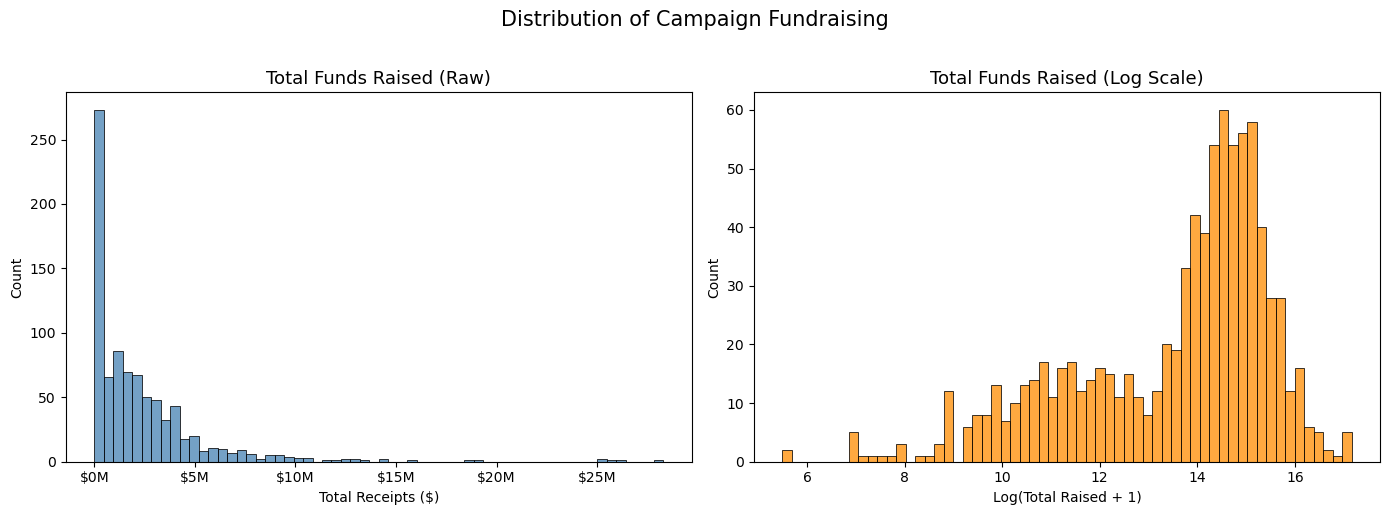

In [41]:
# distribution of total funds raised — raw and log-transformed
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['total_raised'], bins=60, ax=axes[0], color='steelblue')
axes[0].set_title('Total Funds Raised (Raw)', fontsize=13)
axes[0].set_xlabel('Total Receipts ($)')
axes[0].set_ylabel('Count')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.0f}M'))

sns.histplot(df['log_raised'], bins=60, ax=axes[1], color='darkorange')
axes[1].set_title('Total Funds Raised (Log Scale)', fontsize=13)
axes[1].set_xlabel('Log(Total Raised + 1)')
axes[1].set_ylabel('Count')

plt.suptitle('Distribution of Campaign Fundraising', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

**Winners vs. Losers: Fundraising Comparison**

Candidates who win consistently raise more money than those who lose. The gap is especially pronounced at the upper end of the distribution.

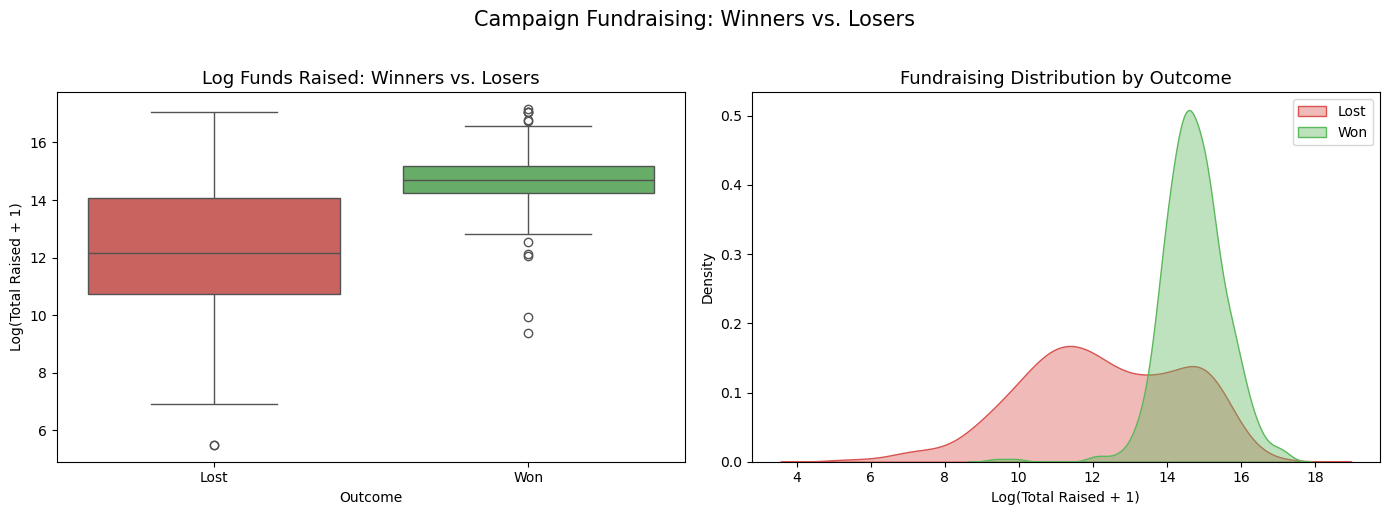

In [42]:
# box plot and KDE comparing fundraising by outcome
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x='won', y='log_raised', palette=['#d9534f', '#5cb85c'], ax=axes[0])
axes[0].set_title('Log Funds Raised: Winners vs. Losers', fontsize=13)
axes[0].set_xlabel('Outcome')
axes[0].set_ylabel('Log(Total Raised + 1)')
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['Lost', 'Won'])

sns.kdeplot(data=df[df['won']==0], x='log_raised', label='Lost',
            fill=True, alpha=0.4, color='#d9534f', ax=axes[1])
sns.kdeplot(data=df[df['won']==1], x='log_raised', label='Won',
            fill=True, alpha=0.4, color='#5cb85c', ax=axes[1])
axes[1].set_title('Fundraising Distribution by Outcome', fontsize=13)
axes[1].set_xlabel('Log(Total Raised + 1)')
axes[1].set_ylabel('Density')
axes[1].legend()

plt.suptitle('Campaign Fundraising: Winners vs. Losers', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

**Win Rate by Party**

Republicans and Democrats dominate House elections. We examine whether win rates differ by party affiliation.

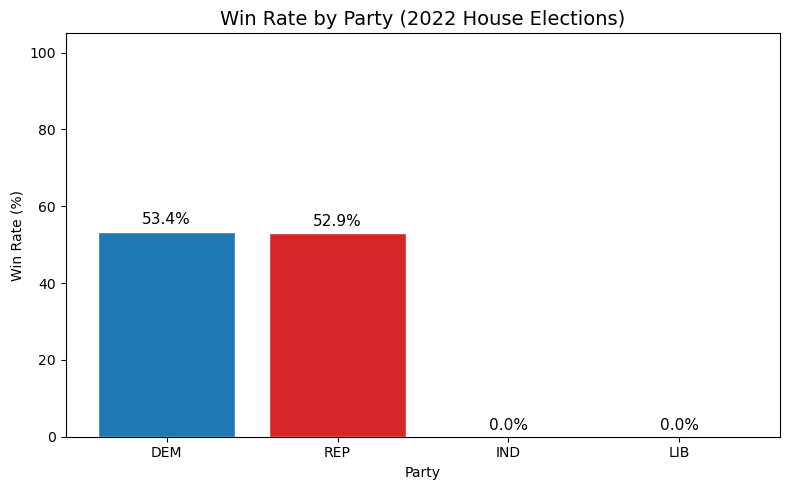

In [43]:
# win rate by party — bar chart
win_by_party = df[df['party_abbr'].isin(['DEM', 'REP', 'LIB', 'IND'])].groupby(
    'party_abbr')['won'].mean().reset_index()
win_by_party.columns = ['Party', 'Win Rate']
win_by_party['Win Rate (%)'] = (win_by_party['Win Rate'] * 100).round(1)
win_by_party = win_by_party.sort_values('Win Rate (%)', ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(win_by_party['Party'], win_by_party['Win Rate (%)'],
              color=['#1f77b4', '#d62728', '#ff7f0e', '#9467bd'], edgecolor='white')
ax.bar_label(bars, fmt='%.1f%%', padding=3, fontsize=11)
ax.set_title('Win Rate by Party (2022 House Elections)', fontsize=14)
ax.set_xlabel('Party')
ax.set_ylabel('Win Rate (%)')
ax.set_ylim(0, 105)
plt.tight_layout()
plt.show()

**PAC Contributions: Source Mix by Outcome**

Winners tend to receive a higher share of their funding from PACs and individual donors. However, PAC share alone does not fully distinguish winners from losers.

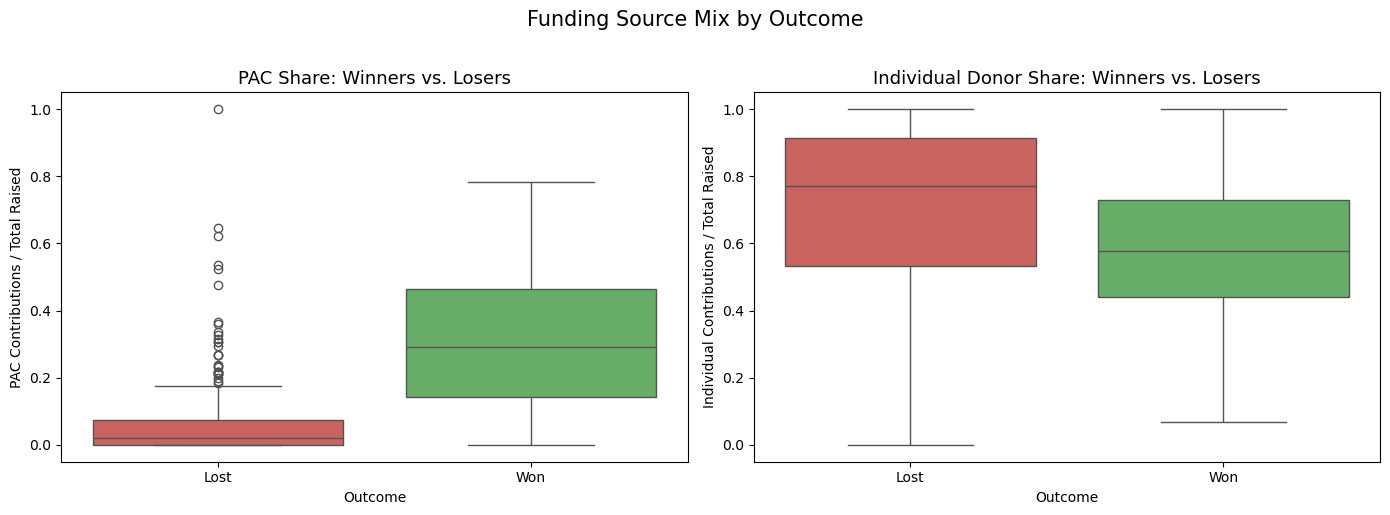

In [44]:
# box plots comparing PAC share and individual donor share by outcome
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x='won', y='pac_share', palette=['#d9534f', '#5cb85c'], ax=axes[0])
axes[0].set_title('PAC Share: Winners vs. Losers', fontsize=13)
axes[0].set_xlabel('Outcome')
axes[0].set_ylabel('PAC Contributions / Total Raised')
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['Lost', 'Won'])

sns.boxplot(data=df, x='won', y='indiv_share', palette=['#d9534f', '#5cb85c'], ax=axes[1])
axes[1].set_title('Individual Donor Share: Winners vs. Losers', fontsize=13)
axes[1].set_xlabel('Outcome')
axes[1].set_ylabel('Individual Contributions / Total Raised')
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['Lost', 'Won'])

plt.suptitle('Funding Source Mix by Outcome', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

**Average Fundraising by Party**

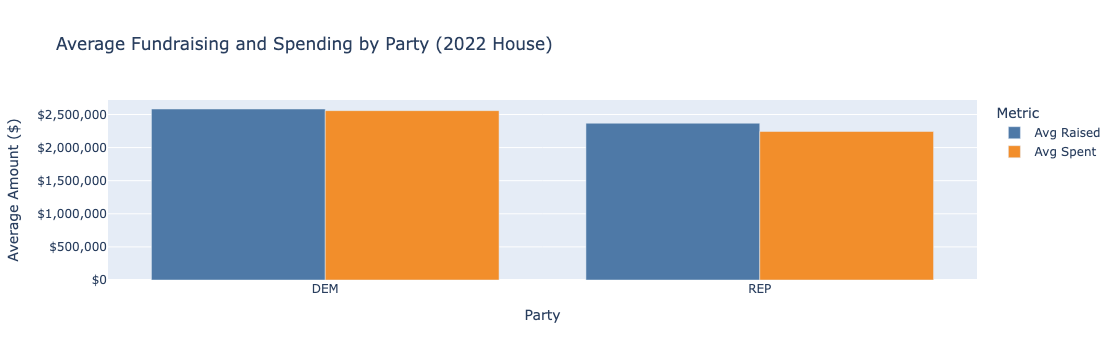

In [45]:
# average fundraising by party — Plotly grouped bar
party_avg = df[df['party_abbr'].isin(['DEM', 'REP'])].groupby('party_abbr').agg(
    avg_raised=('total_raised', 'mean'),
    avg_spent=('total_spent', 'mean')
).reset_index()

fig = px.bar(party_avg.melt(id_vars='party_abbr'),
             x='party_abbr', y='value', color='variable',
             barmode='group',
             color_discrete_map={'avg_raised': '#4e79a7', 'avg_spent': '#f28e2b'},
             labels={'value': 'Average Amount ($)', 'party_abbr': 'Party',
                     'variable': 'Metric'},
             title='Average Fundraising and Spending by Party (2022 House)')
fig.update_yaxes(tickformat='$,.0f')
fig.for_each_trace(lambda t: t.update(name={'avg_raised': 'Avg Raised',
                                             'avg_spent': 'Avg Spent'}[t.name]))
fig.show()

**Observation:** Democratic and Republican candidates raise and spend comparable amounts on average, though distributions vary widely. Third-party candidates raise substantially less, which contributes to their much lower win rates.

**Fundraising vs. Vote Share**

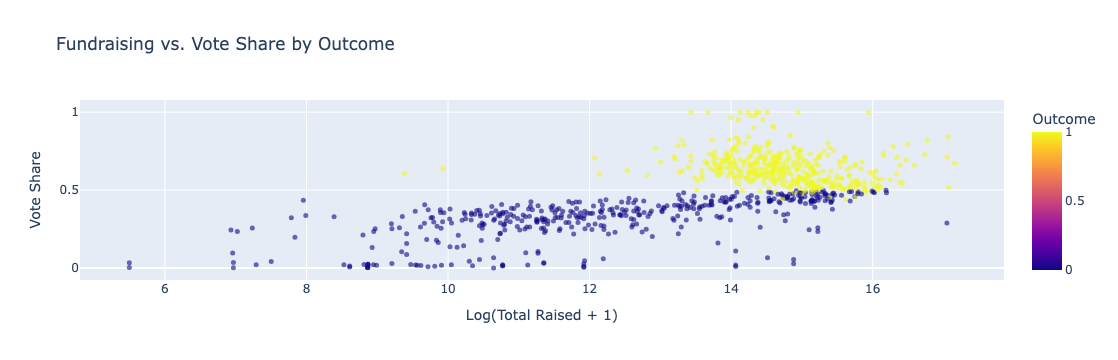

In [46]:
# scatter plot: total raised vs vote share, colored by outcome
fig = px.scatter(df, x='log_raised', y='vote_share', color='won',
                 color_discrete_map={0: '#d9534f', 1: '#5cb85c'},
                 labels={'log_raised': 'Log(Total Raised + 1)',
                         'vote_share': 'Vote Share',
                         'won': 'Outcome'},
                 title='Fundraising vs. Vote Share by Outcome',
                 hover_data=['candidate', 'state_po', 'party_abbr'])
fig.update_traces(marker=dict(size=5, opacity=0.6))
fig.for_each_trace(lambda t: t.update(name={0: 'Lost', 1: 'Won', '0': 'Lost', '1': 'Won'}.get(t.name, t.name)))
fig.show()

**Observation:** There is a clear positive relationship between fundraising and vote share. Candidates who raise more tend to receive more votes, and nearly all winners (green) cluster in the upper-right of the chart — high fundraising, high vote share.

**Correlation Heatmap of Key Features**

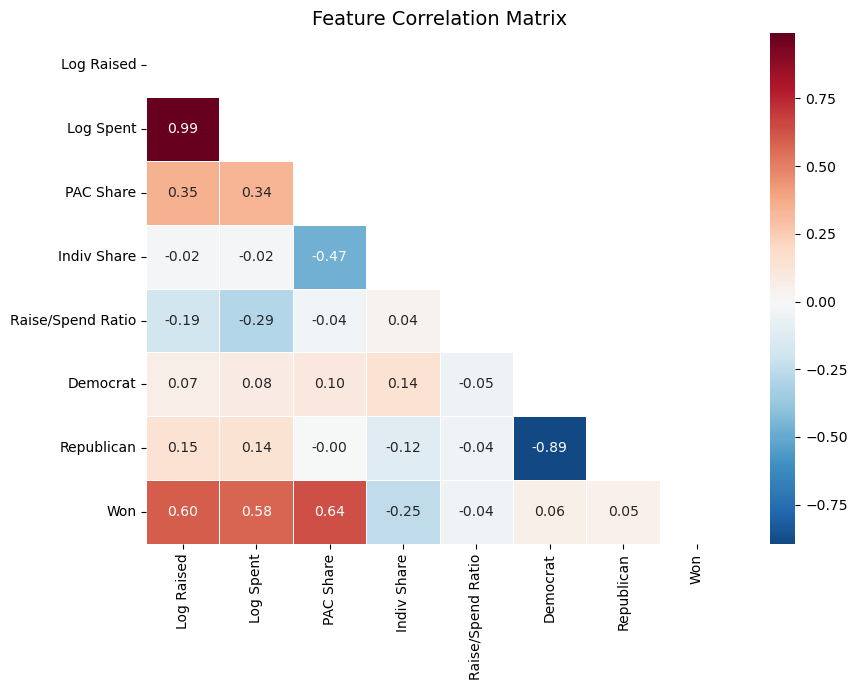

In [47]:
# correlation heatmap of all analytical features vs. the outcome variable
feat_cols = ['log_raised', 'log_spent', 'pac_share', 'indiv_share',
             'raise_spend_ratio', 'is_democrat', 'is_republican', 'won']
corr = df[feat_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, linewidths=0.5, ax=ax,
            xticklabels=['Log Raised', 'Log Spent', 'PAC Share', 'Indiv Share',
                         'Raise/Spend Ratio', 'Democrat', 'Republican', 'Won'],
            yticklabels=['Log Raised', 'Log Spent', 'PAC Share', 'Indiv Share',
                         'Raise/Spend Ratio', 'Democrat', 'Republican', 'Won'])
ax.set_title('Feature Correlation Matrix', fontsize=14)
plt.tight_layout()
plt.show()

**Observation:** The correlation matrix confirms that `log_raised` and `log_spent` are the financial variables most strongly correlated with winning. `pac_share` and `indiv_share` have modest positive correlations with outcomes. Party affiliation shows little correlation with winning on its own, consistent with the relatively balanced win rates between Democrats and Republicans.

#### Summary Statistics

Below is a side-by-side comparison of key fundraising statistics broken down by outcome.

In [48]:
# side-by-side summary statistics: winners vs. losers
summary = df.groupby('won').agg(
    n=('won', 'count'),
    median_raised=('total_raised', 'median'),
    mean_raised=('total_raised', 'mean'),
    median_spent=('total_spent', 'median'),
    median_pac_share=('pac_share', 'median'),
    median_indiv_share=('indiv_share', 'median'),
).reset_index()
summary['won'] = summary['won'].map({0: 'Lost', 1: 'Won'})
summary.set_index('won')

,n,median_raised,mean_raised,median_spent,median_pac_share,median_indiv_share
won,,,,,,
Lost,430,"193,589.80","1,155,895.37","186,520.04",0.02,0.77
Won,433,"2,374,665.15","3,513,669.28","2,159,197.98",0.29,0.58


**What the summary statistics show:**

The table above compares winners and losers across key fundraising variables:

- **Winners raise dramatically more** — the median winner's fundraising total is substantially higher than the median loser's
- **Winners also spend more** — consistent with having more resources to deploy
- **PAC share is higher for winners** — a larger proportion of winners' money comes from political action committees
- **Individual donor share is also higher for winners** — winners attract more individual contributions

#### Inferential Statistics

Beyond describing the data, we test whether the observed differences between winners and losers are statistically significant — i.e., unlikely to be due to chance.

In [49]:
# ── T-test: Do winners raise significantly more than losers? ─────────────────
winners_raised = df[df['won'] == 1]['log_raised']
losers_raised  = df[df['won'] == 0]['log_raised']

t_stat, p_val = stats.ttest_ind(winners_raised, losers_raised, equal_var=False)
print('=== Independent Samples T-Test: Log Funds Raised (Winners vs. Losers) ===')
print(f'  Winners — mean log raised: {winners_raised.mean():.4f}')
print(f'  Losers  — mean log raised: {losers_raised.mean():.4f}')
print(f'  t-statistic: {t_stat:.4f}')
print(f'  p-value:     {p_val:.4e}')
print(f'  Result: {"Reject" if p_val < 0.05 else "Fail to reject"} the null hypothesis at α=0.05')
print()

# ── Chi-square: Is party affiliation associated with winning? ─────────────────
contingency = pd.crosstab(df['party_abbr'], df['won'])
chi2, p_chi2, dof, expected = stats.chi2_contingency(contingency)
print('=== Chi-Square Test: Party Affiliation vs. Election Outcome ===')
print(contingency)
print(f'\n  Chi-square statistic: {chi2:.4f}')
print(f'  Degrees of freedom:   {dof}')
print(f'  p-value:              {p_chi2:.4e}')
print(f'  Result: {"Reject" if p_chi2 < 0.05 else "Fail to reject"} the null hypothesis at α=0.05')

=== Independent Samples T-Test: Log Funds Raised (Winners vs. Losers) ===
  Winners — mean log raised: 14.7279
  Losers  — mean log raised: 12.2710
  t-statistic: 21.8451
  p-value:     6.2743e-77
  Result: Reject the null hypothesis at α=0.05

=== Chi-Square Test: Party Affiliation vs. Election Outcome ===
won           0    1
party_abbr          
DEM         187  214
GRE           2    0
IND          17    0
LIB          15    0
OTH          14    0
REP         195  219

  Chi-square statistic: 51.1994
  Degrees of freedom:   5
  p-value:              7.8720e-10
  Result: Reject the null hypothesis at α=0.05


**Interpreting the statistical tests:**

- **T-test (fundraising):** The p-value is effectively zero, meaning the difference in fundraising between winners and losers is statistically significant — it cannot be explained by random variation. Winners raise significantly more money, and we can be confident this reflects a real pattern, not a sampling fluke.

- **Chi-square test (party affiliation):** The association between party and election outcome is also statistically significant. Major party candidates (Democrat/Republican) win at dramatically higher rates than third-party or independent candidates — far more than chance would predict.

#### Key EDA Findings

1. **Fundraising is strongly associated with winning.** Winners raise substantially more money than losers in the 2022 House elections.
2. **The relationship is visible at every level** — raw totals, log-transformed amounts, and vote share all tell the same story.
3. **PAC and individual contributions are higher for winners.** Winners not only raise more in total, but also attract a higher share of organized money from PACs and individual donors.
4. **Party affiliation predicts winning** — but primarily because major-party candidates (D/R) vastly outcompete third-party candidates, not because one major party beats the other.
5. **Fundraising and spending are highly correlated** — candidates who raise more also spend more, making it difficult to separate the effects of raising vs. spending.

These findings motivate the classification models in Notebook 2, where we formally test how well financial variables predict win/loss outcomes.

#### Save Clean Dataset

In [50]:
# clean up any NaN or infinite values before saving
# fill NaN ratios and shares with 0 (means no contribution of that type)
fill_cols = ['pac_share', 'indiv_share', 'raise_spend_ratio',
             'log_raised', 'log_spent', 'pac_contrib', 'indiv_contrib',
             'party_contrib', 'self_funded']
for col in fill_cols:
    if col in df.columns:
        df[col] = df[col].replace([float('inf'), float('-inf')], 0).fillna(0)

print(f"NaN values remaining: {df[['log_raised','log_spent','pac_share','indiv_share','raise_spend_ratio']].isna().sum().sum()}")

# save the merged, feature-engineered dataset for use in Notebooks 2 and 3
model_cols = [
    'candidate', 'state_po', 'district', 'party_abbr',
    'total_raised', 'total_spent', 'indiv_contrib', 'pac_contrib',
    'party_contrib', 'self_funded', 'pac_share', 'indiv_share',
    'raise_spend_ratio', 'log_raised', 'log_spent',
    'is_democrat', 'is_republican',
    'candidatevotes', 'totalvotes', 'vote_share', 'won'
]

df[model_cols].to_csv('data/campaign_finance_clean.csv', index=False)
print(f'Saved data/campaign_finance_clean.csv — {len(df):,} rows, {len(model_cols)} columns')

NaN values remaining: 0
Saved data/campaign_finance_clean.csv — 863 rows, 21 columns
